<a href="https://colab.research.google.com/github/Saifullah785/Python_for_Data_Science/blob/main/Statistics_for_Data_Science/Lecture_03_Probability_Distribution_Functions_PDF%2C_PMF_%26_CDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import random

In [2]:
# Simulate rolling two dice 10,000 times
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [3]:
# Get the length of the list L
len(L)

10000

In [4]:
# Display the first 5 elements of list L
L[:5]

[8, 10, 5, 7, 9]

In [5]:
# Calculate and sort the probability distribution of the sums
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [6]:
# Calculate the cumulative sum of the probabilities
import numpy as np
np.cumsum(s)

,count
2,0.0291
3,0.0857
4,0.1746
5,0.2845
6,0.4294
7,0.5942
8,0.7278
9,0.8381
10,0.9210
11,0.9732


<Axes: >

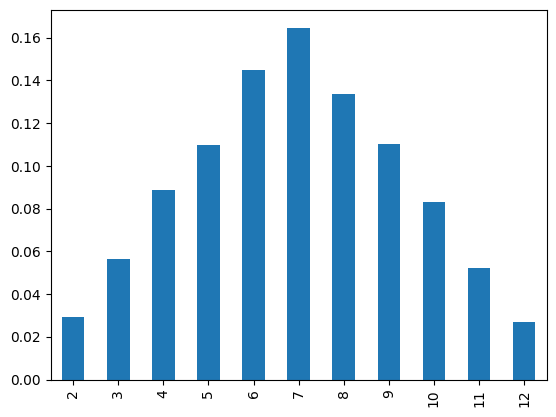

In [7]:
# Plot the probability distribution as a bar chart
s.plot(kind='bar')

<Axes: >

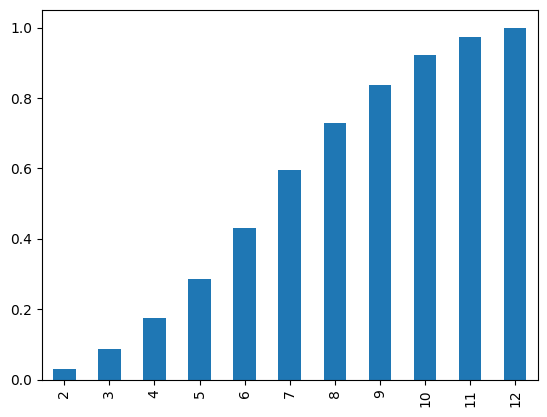

In [8]:
# Plot the cumulative probability distribution as a bar chart
np.cumsum(s).plot(kind='bar')

#**Parametric Density Estimation**

In [9]:
# Generate a sample from a normal distribution
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal


sample = normal(loc=50, scale=5, size=1000)

In [10]:
# Calculate the mean of the sample
sample.mean()

np.float64(49.73694929990013)

(array([  4.,  14.,  40., 108., 182., 256., 209., 116.,  51.,  20.]),
 array([32.92942766, 35.94215528, 38.9548829 , 41.96761053, 44.98033815,
        47.99306577, 51.00579339, 54.01852101, 57.03124863, 60.04397625,
        63.05670387]),
 <BarContainer object of 10 artists>)

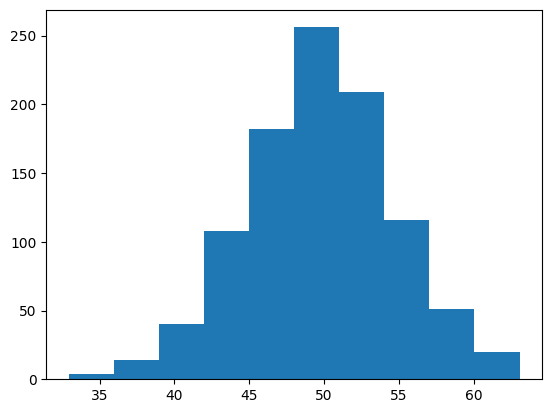

In [11]:
# plot histogram to understand the distribution of data
plt.hist(sample, bins=10)

In [12]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [13]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(60, 12)

In [14]:
# Create an array of values for plotting the PDF
values = np.linspace(sample.min(),sample.max(),100)

In [15]:
# Get the maximum value of the sample
sample.max()

np.float64(63.05670387187159)

In [16]:
# Calculate the probability density for each value
probabilities = [dist.pdf(value) for value in values]

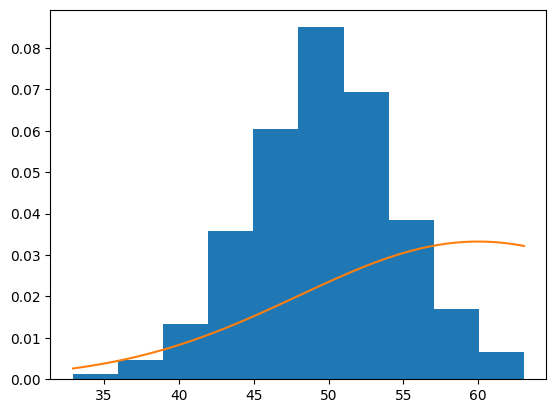

In [17]:
# plot the histogram and pdf
plt.hist(sample, bins=10, density=True)
plt.plot(values, probabilities)

/tmp/ipython-input-1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

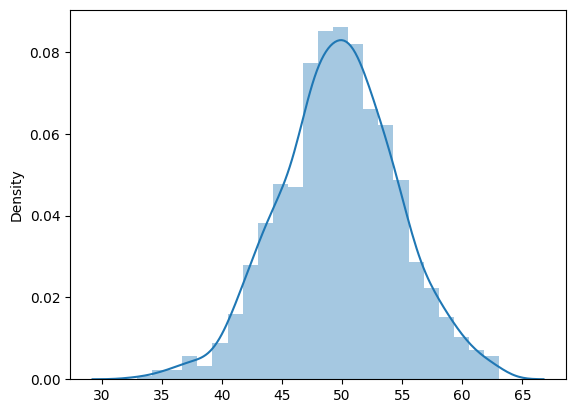

In [18]:
# Plot the distribution using seaborn distplot
import seaborn as sns
sns.distplot(sample)

# KDE

In [19]:
# Generate a bimodal sample distribution
sample = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample, sample2))

In [20]:
# Display the generated sample data
sample

array([19.69461084, 20.41478259, 19.37860431, 13.17044247, 16.48480502,
       29.45947257, 28.23283551, 21.75131773, 27.10506077, 18.85143837,
       22.625455  , 14.69656073, 18.2794176 , 17.59701017, 12.15465203,
       19.74632829, 14.29212566, 24.6395094 , 20.58088515, 19.41656681,
       19.10247357, 22.71090704, 13.8234293 , 20.36186633, 15.02325861,
       21.62745516, 17.62683505, 13.56402195, 20.50722064, 26.91949183,
       18.01187062, 25.51667418, 22.74180962,  7.17302702, 17.16459302,
       21.65083853, 22.38195598, 15.25910059, 21.50372867, 23.65882113,
       22.66578068, 28.86297307, 27.29217142, 23.21118383, 25.12196815,
       17.13843439, 25.01106885, 19.81292157, 17.65012399, 16.1306304 ,
       29.11486316, 16.76416135, 17.99803543, 25.86513241, 15.83087319,
       30.76048271, 19.0328267 , 24.31313586, 17.022279  , 21.07937188,
       17.65214001, 21.32314771, 17.93576136, 19.70866601, 16.77695524,
       24.52498623, 20.08202824, 19.64481923, 20.90006114, 28.19

(array([ 1.,  2.,  1.,  2.,  3.,  6.,  5., 16., 18., 14., 21., 13., 23.,
        31., 19., 21., 28., 13., 16., 12.,  9.,  9., 14., 10., 12., 16.,
        11., 22., 31., 45., 35., 50., 41., 57., 53., 60., 49., 51., 44.,
        30., 19., 18., 13., 14., 11.,  2.,  4.,  1.,  0.,  4.]),
 array([ 5.94727524,  6.94393896,  7.94060269,  8.93726641,  9.93393013,
        10.93059386, 11.92725758, 12.9239213 , 13.92058503, 14.91724875,
        15.91391247, 16.9105762 , 17.90723992, 18.90390365, 19.90056737,
        20.89723109, 21.89389482, 22.89055854, 23.88722226, 24.88388599,
        25.88054971, 26.87721344, 27.87387716, 28.87054088, 29.86720461,
        30.86386833, 31.86053205, 32.85719578, 33.8538595 , 34.85052323,
        35.84718695, 36.84385067, 37.8405144 , 38.83717812, 39.83384184,
        40.83050557, 41.82716929, 42.82383302, 43.82049674, 44.81716046,
        45.81382419, 46.81048791, 47.80715163, 48.80381536, 49.80047908,
        50.79714281, 51.79380653, 52.79047025, 53.78713398,

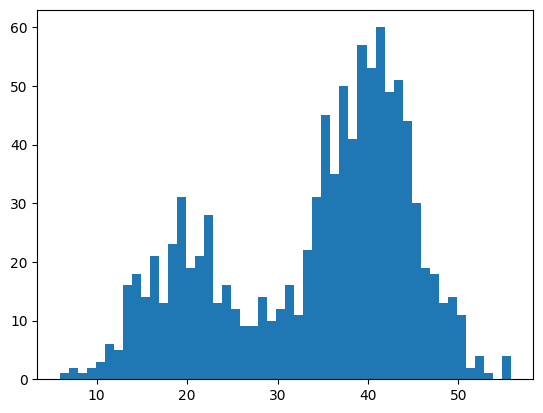

In [21]:
# Plot a histogram of the bimodal sample
plt.hist(sample, bins=50)

In [22]:
# Initialize and fit a Kernel Density Estimation model
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=5)

In [23]:
# Prepare values for KDE plotting
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [24]:
# Calculate the probability densities from the KDE model
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

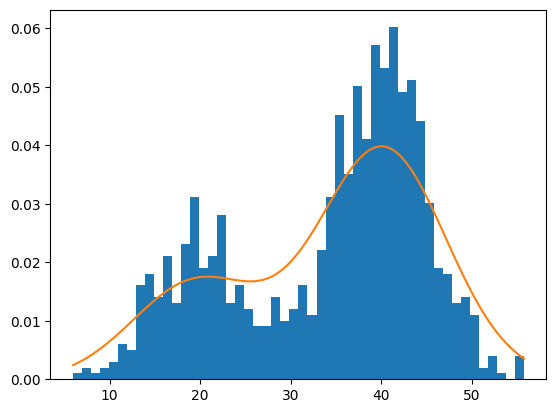

In [25]:
# Plot the histogram and KDE curve
plt.hist(sample, bins =50, density=True)
plt.plot(values, probabilities)
plt.show()

<Axes: ylabel='Density'>

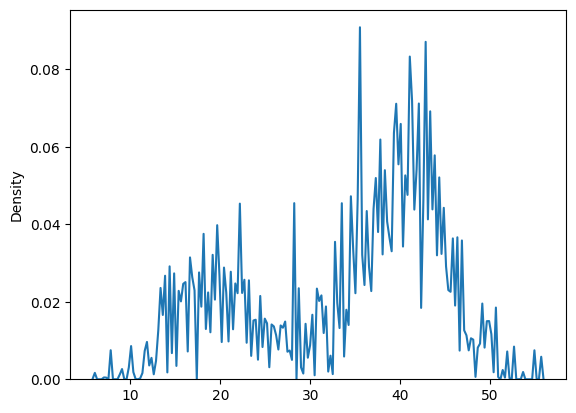

In [26]:
# Plot Kernel Density Estimate using seaborn
sns.kdeplot(sample.reshape(1000), bw_adjust=0.02)

In [27]:
# Import the seaborn library
import seaborn as sns

In [28]:
# Load the Iris dataset from seaborn
df = sns.load_dataset('iris')

In [29]:
# Display the first few rows of the Iris DataFrame
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

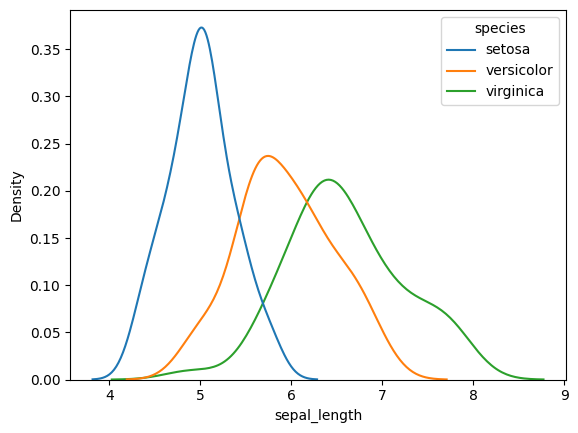

In [30]:
# Plot KDE for sepal length by species
sns.kdeplot(data=df, x='sepal_length', hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

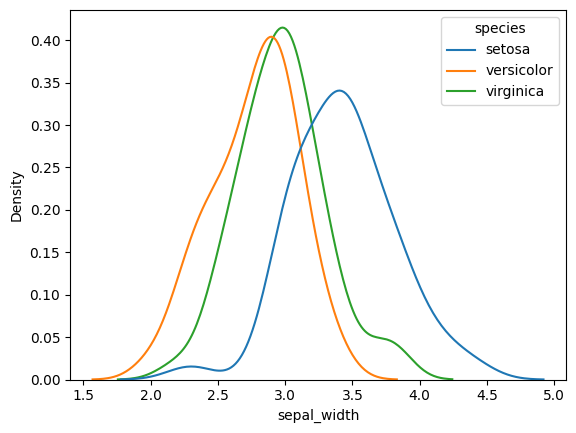

In [31]:
# Plot KDE for sepal width by species
sns.kdeplot(data=df, x = 'sepal_width', hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

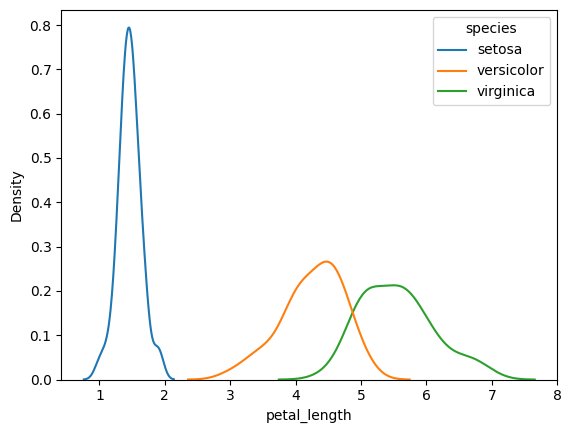

In [32]:
# Plot KDE for petal length by species
sns.kdeplot(data=df, x = 'petal_length', hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

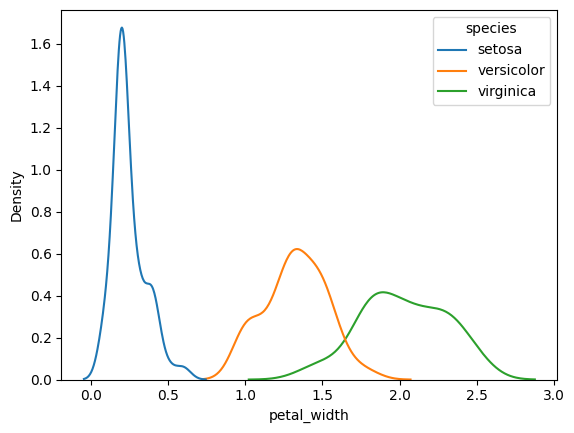

In [33]:
# Plot KDE for petal width by species
sns.kdeplot(data=df, x = 'petal_width', hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

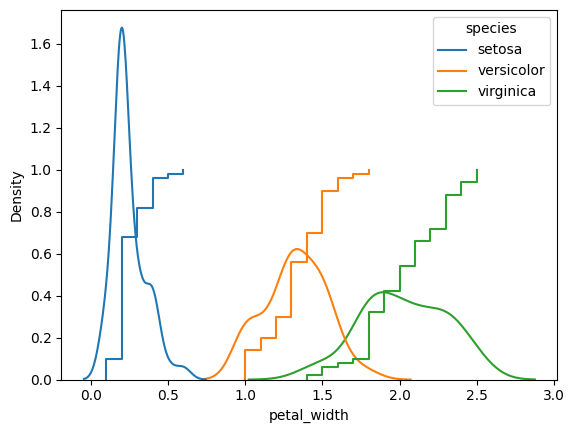

In [34]:
# Plot KDE and ECDF for petal width by species
sns.kdeplot(data=df, x='petal_width', hue='species')
sns.ecdfplot(data=df, x='petal_width',hue='species')

In [35]:
# Load the Titanic dataset from a URL
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [36]:
# Display the first few rows of the Titanic DataFrame
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

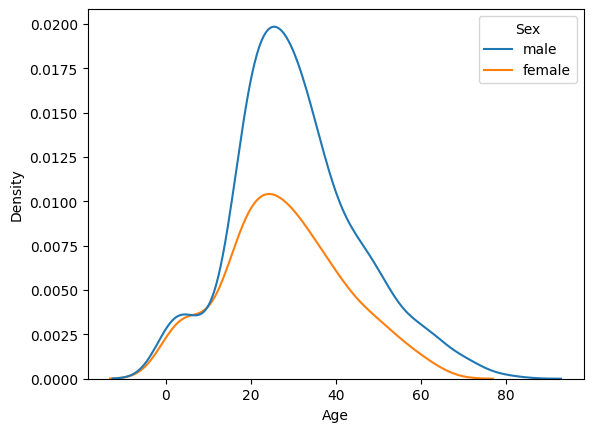

In [37]:
# Plot KDE for Age on Titanic dataset, separated by Sex
sns.kdeplot(data=titanic, x='Age', hue='Sex')

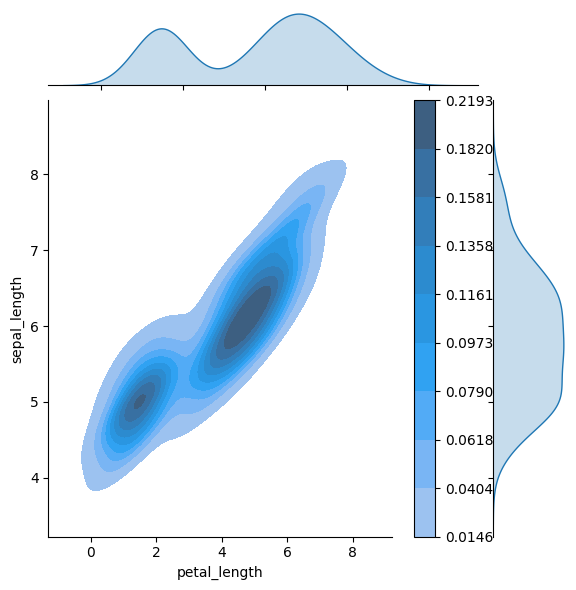

In [39]:
# Create a joint plot of petal length and sepal length with KDE
sns.jointplot(data=df, x ="petal_length", y="sepal_length", kind="kde",fill=True, cbar=True)

<Axes: xlabel='Age', ylabel='Density'>

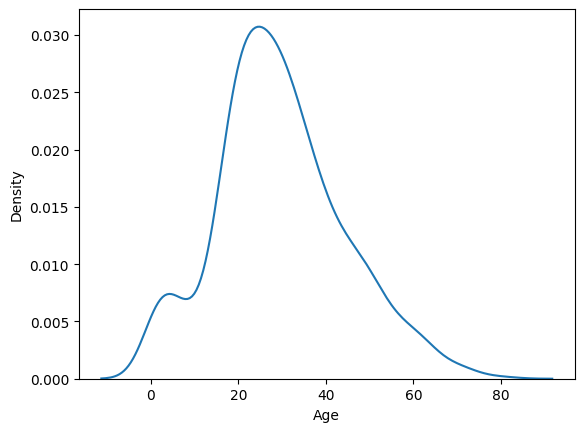

In [40]:
# Plot KDE for the Age column of the Titanic dataset
sns.kdeplot(titanic['Age'])

In [41]:
# Calculate the mean of the Age column
titanic['Age'].mean()

np.float64(29.69911764705882)

In [43]:
# Standardize the Age column
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()

<Axes: xlabel='Age', ylabel='Density'>

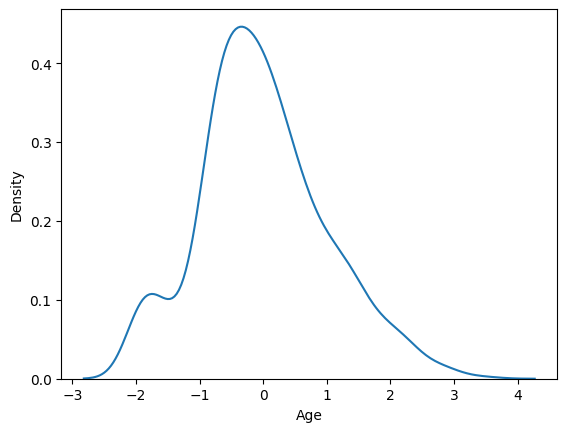

In [44]:
# Plot KDE for the standardized Age column
sns.kdeplot(x)

In [45]:
# Calculate the mean of the standardized Age column
x.mean()

np.float64(2.388378943731429e-16)

In [46]:
# Calculate the standard deviation of the standardized Age column
x.std()

0.9999999999999994

In [47]:
# Calculate the skewness of the Age column
titanic['Age'].skew()

np.float64(0.38910778230082704)

In [48]:
# Calculate three standard deviations above the mean age
titanic['Age'].mean() + 3*titanic['Age'].std()

np.float64(73.27860964406095)

In [49]:
# Calculate three standard deviations below the mean age
titanic['Age'].mean() - 3*titanic['Age'].std()

np.float64(-13.88037434994331)

In [50]:
# Filter the Titanic data for passengers older than 73
titanic[titanic['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [51]:
# Find the maximum age in the Titanic dataset
titanic['Age'].max()

80.0